      date  precip_mm   pet_mm  qsim_mm_day
2020-01-01   0.000000 3.000000     0.724400
2020-01-02   0.000000 3.025820     0.677185
2020-01-03   4.657939 3.051632     0.637264
2020-01-04   0.000000 3.077430     0.606421
2020-01-05   0.000000 3.103204     0.578672
2020-01-06   0.000000 3.128947     0.545313
2020-01-07   3.647485 3.154653     0.515203
2020-01-08   0.000000 3.180312     0.490730
2020-01-09   7.240084 3.205918     0.472275
2020-01-10   0.000000 3.231463     0.463212


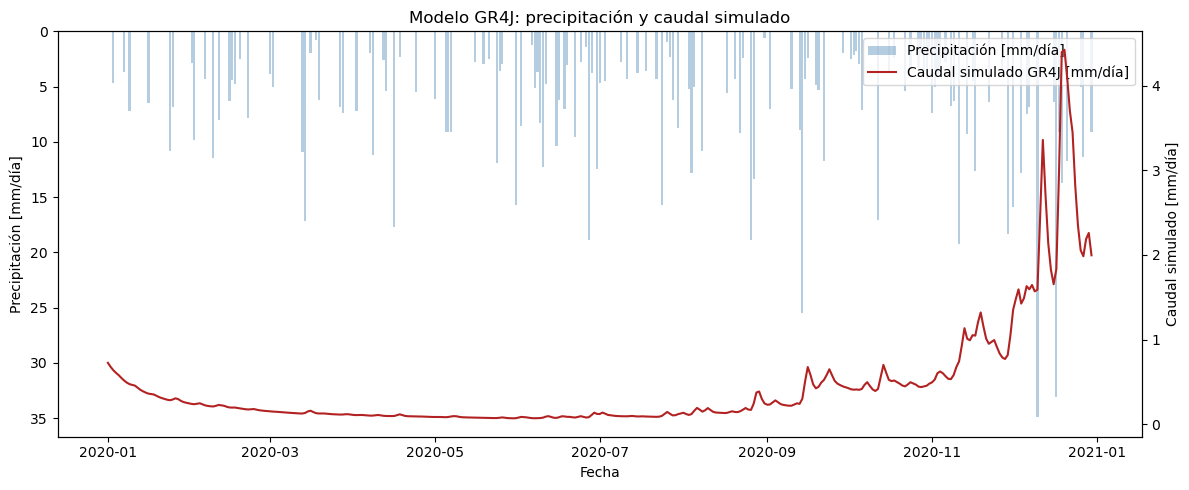

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Funciones auxiliares: curvas S del modelo GR4J
# ============================================================

def s_curve1(t, x4):
    """
    Curva S para el hidrograma unitario UH1 del modelo GR4J.

    Parámetros
    ----------
    t : float o array
        Tiempo en días.
    x4 : float
        Tiempo base del hidrograma unitario (>= 0.5).

    Retorna
    -------
    float o array
        Valor acumulado de la curva S1 en [0, 1].
    """
    t = np.asarray(t, dtype=float)
    result = np.zeros_like(t)

    mask1 = (t > 0) & (t < x4)
    mask2 = t >= x4

    result[mask1] = (t[mask1] / x4) ** 2.5
    result[mask2] = 1.0

    return result


def s_curve2(t, x4):
    """
    Curva S para el hidrograma unitario UH2 del modelo GR4J.

    Parámetros
    ----------
    t : float o array
        Tiempo en días.
    x4 : float
        Tiempo base del hidrograma unitario (>= 0.5).

    Retorna
    -------
    float o array
        Valor acumulado de la curva S2 en [0, 1].
    """
    t = np.asarray(t, dtype=float)
    result = np.zeros_like(t)

    mask1 = (t > 0) & (t <= x4)
    mask2 = (t > x4) & (t < 2 * x4)
    mask3 = t >= 2 * x4

    result[mask1] = 0.5 * (t[mask1] / x4) ** 2.5
    result[mask2] = 1.0 - 0.5 * (2 - t[mask2] / x4) ** 2.5
    result[mask3] = 1.0

    return result


def unit_hydrographs(x4):
    """
    Calcula los hidrogramas unitarios discretos UH1 y UH2.

    Parámetros
    ----------
    x4 : float
        Tiempo base del hidrograma unitario (>= 0.5).

    Retorna
    -------
    uh1 : ndarray
        Hidrograma unitario 1 (suma = 1).
    uh2 : ndarray
        Hidrograma unitario 2 (suma = 1).
    """
    n_uh1 = max(1, int(np.ceil(x4)))
    n_uh2 = max(2, int(np.ceil(2 * x4)))

    t1 = np.arange(1, n_uh1 + 1)
    t2 = np.arange(1, n_uh2 + 1)

    uh1 = s_curve1(t1, x4) - s_curve1(t1 - 1, x4)
    uh2 = s_curve2(t2, x4) - s_curve2(t2 - 1, x4)

    return uh1, uh2


# ============================================================
# 2. Modelo hidrológico GR4J
# ============================================================

def gr4j(precip, pet, params, states=None, return_storage=True):
    """
    Modelo hidrológico GR4J diario (Perrin et al., 2003).

    Parámetros
    ----------
    precip : array-like
        Precipitación diaria [mm/día]. Debe ser >= 0.
    pet : array-like
        Evapotranspiración potencial diaria [mm/día]. Debe ser >= 0.
    params : dict
        Parámetros del modelo:
            x1 : capacidad del reservorio de producción [mm]  (> 0)
            x2 : coeficiente de intercambio subterráneo [mm/día] (puede ser negativo)
            x3 : capacidad del reservorio de enrutamiento [mm] (> 0)
            x4 : tiempo base del hidrograma unitario [días]  (>= 0.5)
    states : dict, opcional
        Estados iniciales:
            S : almacenamiento inicial del reservorio de producción [mm]
            R : almacenamiento inicial del reservorio de enrutamiento [mm]
        Por defecto S = 0.3·x1, R = 0.5·x3.
    return_storage : bool, opcional
        Si True (por defecto), retorna también el DataFrame de estados internos.
        Poner False en calibración intensiva para ahorrar memoria.

    Retorna
    -------
    qsim : ndarray
        Caudal simulado [mm/día].
    storage : DataFrame o None
        Evolución de los reservorios S y R (None si return_storage=False).

    Referencias
    -----------
    Perrin, C., Michel, C., Andréassian, V. (2003). Improvement of a parsimonious
    model for streamflow simulation. Journal of Hydrology, 279(1-4), 275-289.
    """

    precip = np.asarray(precip, dtype=float)
    pet    = np.asarray(pet,    dtype=float)

    if precip.ndim != 1 or pet.ndim != 1:
        raise ValueError("precip y pet deben ser arrays 1D.")
    if len(precip) != len(pet):
        raise ValueError("precip y pet deben tener la misma longitud.")
    if np.any(precip < 0):
        raise ValueError("La precipitación no puede contener valores negativos.")
    if np.any(pet < 0):
        raise ValueError("La ETP no puede contener valores negativos.")

    # --- Parámetros ---
    x1 = float(params["x1"])
    x2 = float(params["x2"])   # puede ser negativo (pérdida subterránea)
    x3 = float(params["x3"])
    x4 = float(params["x4"])

    if x1 <= 0:
        raise ValueError(f"x1 debe ser > 0 (recibido: {x1}).")
    if x3 <= 0:
        raise ValueError(f"x3 debe ser > 0 (recibido: {x3}).")
    if x4 < 0.5:
        raise ValueError(
            f"x4 debe ser >= 0.5 días para evitar hidrogramas degenerados "
            f"(recibido: {x4}). GR4J no está definido para x4 < 0.5."
        )

    n = len(precip)

    # --- Hidrogramas unitarios ---
    uh1, uh2 = unit_hydrographs(x4)

    # --- Estados iniciales ---
    if states is None:
        S = 0.3 * x1
        R = 0.5 * x3
    else:
        S = float(states.get("S", 0.3 * x1))
        R = float(states.get("R", 0.5 * x3))

    # Clamp de seguridad en los estados iniciales
    S = max(0.0, min(S, x1))
    R = max(0.0, min(R, x3))

    # --- Colas de convolución ---
    queue_uh1 = np.zeros(len(uh1))
    queue_uh2 = np.zeros(len(uh2))

    qsim    = np.zeros(n)
    s_store = np.zeros(n) if return_storage else None
    r_store = np.zeros(n) if return_storage else None

    for i in range(n):

        P = precip[i]
        E = pet[i]

        # --------------------------------------------------
        # 2.1 Balance P - E y llenado/vaciado del reservorio
        #     de producción
        # --------------------------------------------------
        if P >= E:
            Pn = P - E

            tanh_Pn = np.tanh(Pn / x1)
            ratio_S = S / x1

            Ps = (
                x1
                * (1.0 - ratio_S ** 2)
                * tanh_Pn
                / (1.0 + ratio_S * tanh_Pn)
            )
            Es = 0.0

        else:
            En = E - P

            tanh_En = np.tanh(En / x1)
            ratio_S = S / x1

            Es = (
                S
                * (2.0 - ratio_S)
                * tanh_En
                / (1.0 + (1.0 - ratio_S) * tanh_En)
            )
            Ps = 0.0
            Pn = 0.0

        # Actualización con clamp para evitar deriva numérica
        S = max(0.0, min(S + Ps - Es, x1))

        # --------------------------------------------------
        # 2.2 Percolación desde el reservorio de producción
        # --------------------------------------------------
        # S / x1 ∈ [0, 1] → Perc ∈ [0, S)
        inner = 1.0 + (4.0 / 9.0 * S / x1) ** 4
        Perc = S * (1.0 - inner ** (-0.25))
        S = max(0.0, S - Perc)

        # Lluvia efectiva total
        Pr = Perc + (Pn - Ps)

        # --------------------------------------------------
        # 2.3 Separación en dos ramas (90 % / 10 %)
        # --------------------------------------------------
        Pr_uh1 = 0.9 * Pr
        Pr_uh2 = 0.1 * Pr

        # Convolución discreta mediante cola circular
        queue_uh1 += uh1 * Pr_uh1
        queue_uh2 += uh2 * Pr_uh2

        Q9 = queue_uh1[0]
        Q1 = queue_uh2[0]

        queue_uh1[:-1] = queue_uh1[1:]
        queue_uh1[-1]  = 0.0

        queue_uh2[:-1] = queue_uh2[1:]
        queue_uh2[-1]  = 0.0

        # --------------------------------------------------
        # 2.4 Intercambio subterráneo (x2 puede ser < 0)
        # --------------------------------------------------
        F = x2 * (R / x3) ** 3.5

        # --------------------------------------------------
        # 2.5 Reservorio de enrutamiento
        # --------------------------------------------------
        R = max(0.0, R + Q9 + F)

        inner_R = 1.0 + (R / x3) ** 4
        Qr = R * (1.0 - inner_R ** (-0.25))
        R  = max(0.0, R - Qr)

        # Rama directa (caudal base + intercambio)
        Qd = max(0.0, Q1 + F)

        qsim[i] = Qr + Qd

        if return_storage:
            s_store[i] = S
            r_store[i] = R

    storage = None
    if return_storage:
        storage = pd.DataFrame({
            "S_production_store_mm": s_store,
            "R_routing_store_mm":    r_store,
        })

    return qsim, storage


# ============================================================
# 3. Ejemplo mínimo de uso
# ============================================================

if __name__ == "__main__":

    np.random.seed(42)

    n_days = 365
    dates = pd.date_range("2020-01-01", periods=n_days, freq="D")

    precip = np.random.gamma(shape=1.5, scale=5.0, size=n_days)
    precip[np.random.rand(n_days) < 0.65] = 0.0

    pet = 3.0 + 1.5 * np.sin(2 * np.pi * np.arange(n_days) / 365)

    params = {
        "x1": 350.0,   # capacidad reservorio de producción [mm]
        "x2": 0.5,     # intercambio subterráneo [mm/día]  (puede ser negativo)
        "x3": 90.0,    # capacidad reservorio de enrutamiento [mm]
        "x4": 2.5      # tiempo base hidrograma unitario [días]
    }

    qsim, storage = gr4j(precip=precip, pet=pet, params=params)

    results = pd.DataFrame({
        "date":        dates,
        "precip_mm":   precip,
        "pet_mm":      pet,
        "qsim_mm_day": qsim,
    })

    print(results.head(10).to_string(index=False))

    # --- Figura ---
    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.bar(results["date"], results["precip_mm"],
            alpha=0.4, color="steelblue", label="Precipitación [mm/día]")
    ax1.set_ylabel("Precipitación [mm/día]")
    ax1.invert_yaxis()

    ax2 = ax1.twinx()
    ax2.plot(results["date"], results["qsim_mm_day"],
             color="firebrick", linewidth=1.5, label="Caudal simulado GR4J [mm/día]")
    ax2.set_ylabel("Caudal simulado [mm/día]")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    ax1.set_title("Modelo GR4J: precipitación y caudal simulado")
    ax1.set_xlabel("Fecha")

    fig.tight_layout()
    plt.savefig("gr4j_output.png", dpi=150)
    plt.show()

In [4]:
!pip install hydrogr

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hydrogr import ModelGr4j


# ============================================================
# Comparador entre tu GR4J y hydrogr
# ============================================================

def run_hydrogr_gr4j(dates, precip, pet, params):
    """
    Ejecuta GR4J usando la librería hydrogr.

    Parámetros
    ----------
    dates : array-like
        Fechas diarias.
    precip : array-like
        Precipitación diaria [mm/día].
    pet : array-like
        Evapotranspiración potencial diaria [mm/día].
    params : dict
        Parámetros en el mismo formato usado por tu modelo:
        x1, x2, x3, x4.

    Retorna
    -------
    q_hydrogr : ndarray
        Caudal simulado por hydrogr [mm/día].
    """

    data = pd.DataFrame(
        {
            "precipitation": np.asarray(precip, dtype=float),
            "evapotranspiration": np.asarray(pet, dtype=float),
        },
        index=pd.DatetimeIndex(dates)
    )

    # Asegura frecuencia diaria.
    data = data.asfreq("D")

    parameters_hydrogr = {
        "X1": float(params["x1"]),
        "X2": float(params["x2"]),
        "X3": float(params["x3"]),
        "X4": float(params["x4"]),
    }

    model = ModelGr4j(parameters_hydrogr)

    output = model.run(data)

    q_hydrogr = output["flow"].to_numpy()

    return q_hydrogr


def compare_gr4j_models(dates, precip, pet, params, gr4j_function):
    """
    Compara tu función GR4J contra hydrogr y genera gráficos.

    Parámetros
    ----------
    dates : array-like
        Fechas diarias.
    precip : array-like
        Precipitación diaria [mm/día].
    pet : array-like
        Evapotranspiración potencial diaria [mm/día].
    params : dict
        Parámetros del modelo: x1, x2, x3, x4.
    gr4j_function : function
        Tu función gr4j(precip, pet, params).

    Retorna
    -------
    comparison : DataFrame
        Tabla con ambos resultados y diferencias.
    """

    # Tu modelo
    q_own, _ = gr4j_function(
        precip=precip,
        pet=pet,
        params=params
    )

    # Modelo de referencia hydrogr
    q_hydrogr = run_hydrogr_gr4j(
        dates=dates,
        precip=precip,
        pet=pet,
        params=params
    )

    comparison = pd.DataFrame(
        {
            "date": pd.DatetimeIndex(dates),
            "q_own_mm_day": q_own,
            "q_hydrogr_mm_day": q_hydrogr,
        }
    )

    comparison["difference"] = (
        comparison["q_own_mm_day"] - comparison["q_hydrogr_mm_day"]
    )

    comparison["absolute_difference"] = comparison["difference"].abs()

    # ========================================================
    # Gráfico 1: hidrogramas comparados
    # ========================================================

    plt.figure(figsize=(12, 5))
    plt.plot(
        comparison["date"],
        comparison["q_own_mm_day"],
        label="GR4J propio",
        linewidth=1.8
    )
    plt.plot(
        comparison["date"],
        comparison["q_hydrogr_mm_day"],
        label="GR4J hydrogr",
        linewidth=1.4,
        linestyle="--"
    )

    plt.title("Comparación de caudal simulado: GR4J propio vs hydrogr")
    plt.xlabel("Fecha")
    plt.ylabel("Caudal simulado [mm/día]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ========================================================
    # Gráfico 2: diferencia entre modelos
    # ========================================================

    plt.figure(figsize=(12, 4))
    plt.plot(
        comparison["date"],
        comparison["difference"],
        label="Diferencia: propio - hydrogr",
        linewidth=1.5
    )
    plt.axhline(0, linewidth=1)

    plt.title("Diferencia entre implementaciones GR4J")
    plt.xlabel("Fecha")
    plt.ylabel("Diferencia [mm/día]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ========================================================
    # Métricas simples de comparación
    # ========================================================

    mae = comparison["absolute_difference"].mean()
    rmse = np.sqrt(np.mean(comparison["difference"] ** 2))
    max_abs_error = comparison["absolute_difference"].max()

    print("Resumen de comparación")
    print("----------------------")
    print(f"MAE  : {mae:.8f} mm/día")
    print(f"RMSE : {rmse:.8f} mm/día")
    print(f"Error absoluto máximo: {max_abs_error:.8f} mm/día")

    return comparison

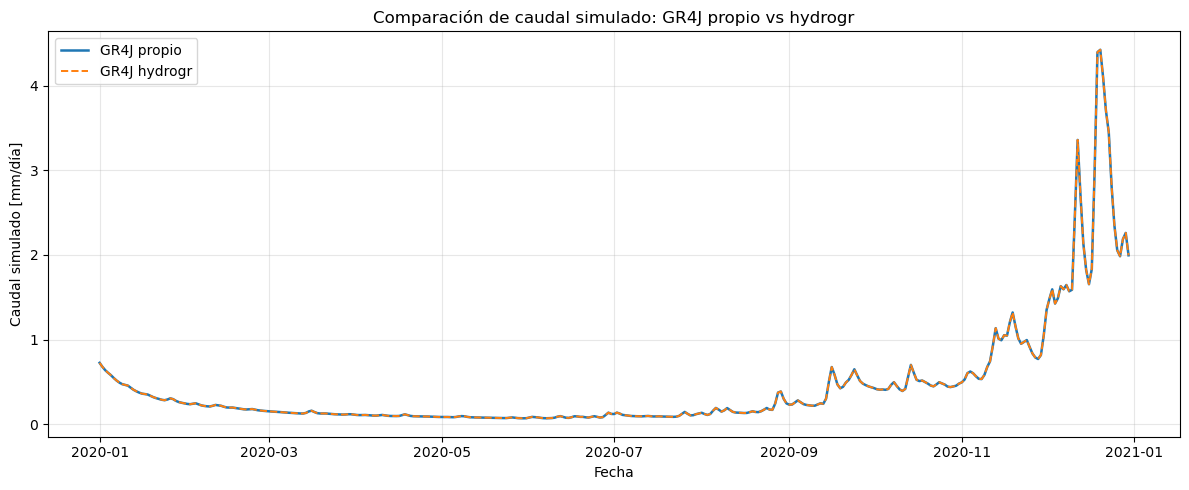

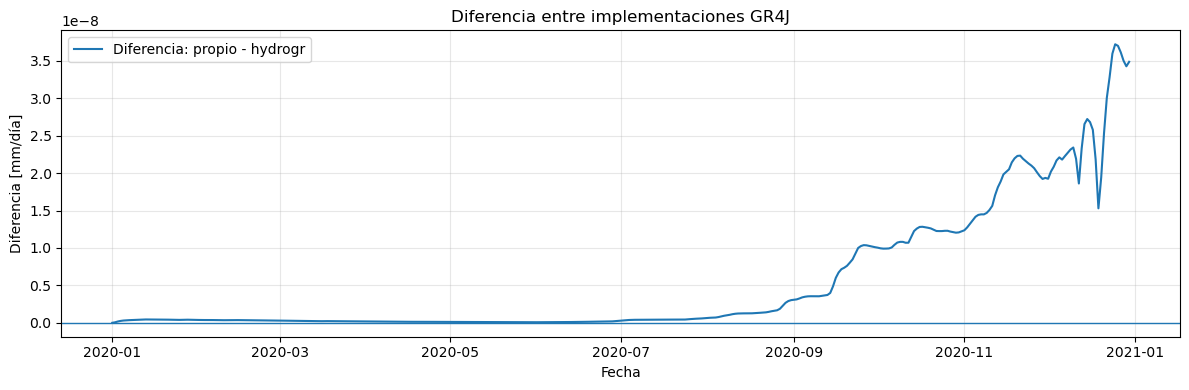

Resumen de comparación
----------------------
MAE  : 0.00000001 mm/día
RMSE : 0.00000001 mm/día
Error absoluto máximo: 0.00000004 mm/día


In [6]:
# Ejemplo con datos sintéticos

np.random.seed(42)

n_days = 365
dates = pd.date_range("2020-01-01", periods=n_days, freq="D")

precip = np.random.gamma(shape=1.5, scale=5.0, size=n_days)
precip[np.random.rand(n_days) < 0.65] = 0.0

pet = 3.0 + 1.5 * np.sin(2 * np.pi * np.arange(n_days) / 365)

params = {
    "x1": 350.0,
    "x2": 0.5,
    "x3": 90.0,
    "x4": 2.5,
}

comparison = compare_gr4j_models(
    dates=dates,
    precip=precip,
    pet=pet,
    params=params,
    gr4j_function=gr4j  # aquí va tu función creada antes
)

In [7]:
import numpy as np
import pandas as pd


def validate_gr4j_comparison(comparison, atol=1e-6, rtol=1e-6):
    """
    Valida si dos implementaciones de GR4J producen resultados equivalentes.

    Parámetros
    ----------
    comparison : DataFrame
        Debe contener las columnas:
        - q_own_mm_day
        - q_hydrogr_mm_day
    atol : float
        Tolerancia absoluta.
    rtol : float
        Tolerancia relativa.

    Retorna
    -------
    metrics : dict
        Métricas de diferencia entre ambas implementaciones.
    """

    q_own = comparison["q_own_mm_day"].to_numpy()
    q_ref = comparison["q_hydrogr_mm_day"].to_numpy()

    diff = q_own - q_ref

    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff ** 2))
    max_abs_error = np.max(np.abs(diff))

    is_equivalent = np.allclose(
        q_own,
        q_ref,
        atol=atol,
        rtol=rtol,
        equal_nan=True
    )

    metrics = {
        "MAE_mm_day": mae,
        "RMSE_mm_day": rmse,
        "Max_abs_error_mm_day": max_abs_error,
        "Equivalent": is_equivalent
    }

    print("Validación GR4J propio vs GR4J hydrogr")
    print("---------------------------------------")
    print(f"MAE              : {mae:.12e} mm/día")
    print(f"RMSE             : {rmse:.12e} mm/día")
    print(f"Error máximo abs.: {max_abs_error:.12e} mm/día")

    if is_equivalent:
        print("Resultado        : PASS. Las implementaciones son equivalentes.")
    else:
        print("Resultado        : REVISAR. Hay diferencias mayores a la tolerancia.")

    return metrics

In [8]:
metrics = validate_gr4j_comparison(comparison)

Validación GR4J propio vs GR4J hydrogr
---------------------------------------
MAE              : 5.392915019614e-09 mm/día
RMSE             : 1.012100440915e-08 mm/día
Error máximo abs.: 3.719524421797e-08 mm/día
Resultado        : PASS. Las implementaciones son equivalentes.
